In [16]:
import pandas as pd

In [17]:
df=pd.read_csv('customer_shopping_behavior.csv')
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

(array([224., 154., 136., 166., 318., 152., 146., 182., 299., 149., 141.,
        162., 329., 169., 147., 158., 309., 148., 144., 230.]),
 array([2.5  , 2.625, 2.75 , 2.875, 3.   , 3.125, 3.25 , 3.375, 3.5  ,
        3.625, 3.75 , 3.875, 4.   , 4.125, 4.25 , 4.375, 4.5  , 4.625,
        4.75 , 4.875, 5.   ]),
 <BarContainer object of 20 artists>)

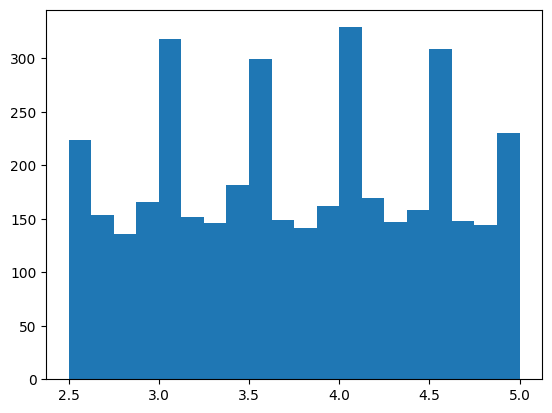

In [18]:
import matplotlib.pyplot as plt
plt.hist(df['Review Rating'],bins=20)


In [19]:
df['Review Rating']=df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [20]:
df=df.rename(columns={'Purchase Amount (USD)':'purchase_amount'})
df.columns=df.columns.str.lower().str.replace(' ','_')
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [21]:
df['age_group']=pd.qcut(df['age'],q=4,labels=['young','adult','middle_aged','senior'])

In [22]:
df[['age','age_group']].head(10)

,age,age_group
0,55,middle_aged
1,19,young
2,50,middle_aged
3,21,young
4,45,middle_aged
5,46,middle_aged
6,63,senior
7,27,young
8,26,young
9,57,middle_aged


In [23]:
df['frequency_of_purchases'].unique()

array(['Fortnightly', 'Weekly', 'Annually', 'Quarterly', 'Bi-Weekly',
       'Monthly', 'Every 3 Months'], dtype=object)

In [24]:
frequency_mapping={
    'Fortnightly': 14,
    'Weekly': 7,
    'Annually': 365,
    'Quarterly': 91,
    'Bi-Weekly': 14,
    'Monthly': 30,
    'Every 3 Months': 90
}

df['frequency_of_purchases_days']=df['frequency_of_purchases'].map(frequency_mapping)

In [25]:
df=df.drop(columns=['promo_code_used'],axis=1)

In [35]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus   # ← add this

username = 'root'
password = quote_plus('@Aks8799golu')         # ← wraps special characters safely
host = 'localhost'
port = '3306'
database = 'customer_behavior'

engine = create_engine(f'mysql+pymysql://{username}:{password}@{host}:{port}/{database}')

# Test connection
with engine.connect() as conn:
    print("✅ Connected successfully!")

# Insert data
df.to_sql('customer', engine, if_exists='replace', index=False)
print("✅ Data inserted successfully!")

✅ Connected successfully!
✅ Data inserted successfully!
